<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
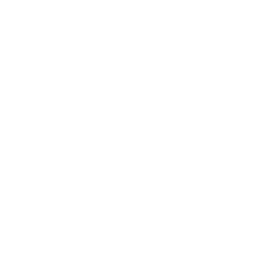
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">NLP Survey Response Classification</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Classify open-text employee survey responses by sentiment and theme &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

An HR analytics team collects annual engagement survey responses across six business units. Free-text comments are the richest signal but impossible to read manually. This notebook generates a synthetic batch of verbatim responses, passes them to Python for TF-IDF vectorization and sentiment classification (positive / neutral / negative) plus keyword-based theme tagging, and returns the scored records as a SAS dataset for aggregation by business unit. The demonstration runs on a 100-response sample; the same pipeline scales unchanged to a full survey census.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| WORK.SURVEY_RESPONSES | 100 | Employee ID, business unit, verbatim comment, rating |
| WORK.CLASSIFIED | 100 | Original fields plus sentiment score, sentiment label, and top theme |
| WORK.SENTIMENT_SUMMARY | 56 | Response counts and mean sentiment by business unit, theme, and sentiment label |

---

In [1]:
/* Generate synthetic employee engagement survey responses */
data work.survey_responses;
    call streaminit(42);
    length employee_id $8 business_unit $30 verbatim $500;
    array bus[6] $30 _temporary_
        ('Sales' 'Engineering' 'Finance' 'HR' 'Operations' 'Marketing');
    array pos_comments[10] $500 _temporary_ (
        'My manager is very supportive and gives clear feedback on my work.',
        'The team culture here is fantastic, people really help each other.',
        'I have great opportunities to grow and learn new skills in this role.',
        'Work life balance has improved significantly over the past year.',
        'Leadership communicates the company vision clearly and consistently.',
        'I feel recognized and appreciated for the contributions I make.',
        'The onboarding process was well organized and made me feel welcome.',
        'Collaboration across teams has gotten much better with the new tools.',
        'My compensation is fair and the benefits package is competitive.',
        'I am proud to work here and would recommend this company to friends.'
    );
    array neg_comments[10] $500 _temporary_ (
        'There is too much bureaucracy and it slows down every decision.',
        'My manager rarely gives feedback and I do not know where I stand.',
        'Work life balance is terrible, I work evenings and weekends constantly.',
        'Communication from senior leadership is poor and inconsistent.',
        'There are not enough growth opportunities in my current team.',
        'The tools and technology we use are outdated and frustrating.',
        'I feel undervalued and my compensation does not reflect my contribution.',
        'There is too much politics here and it affects team morale badly.',
        'Processes are unclear and change too frequently without explanation.',
        'Meetings are excessive and leave no time for focused productive work.'
    );
    do i = 1 to 100;
        employee_id = cats('EMP', put(i, z5.));
        business_unit = bus[ceil(6 * rand('uniform'))];
        overall_rating = round(1 + 4 * rand('uniform'));
        /* Skew comment sentiment with rating */
        if overall_rating >= 4 then
            verbatim = pos_comments[ceil(10 * rand('uniform'))];
        else if overall_rating <= 2 then
            verbatim = neg_comments[ceil(10 * rand('uniform'))];
        else do;
            if rand('uniform') < 0.5 then
                verbatim = pos_comments[ceil(10 * rand('uniform'))];
            else
                verbatim = neg_comments[ceil(10 * rand('uniform'))];
        end;
        survey_year = 2025;
        output;
    end;
    drop i;
run;

NOTE: DATA work.survey_responses


NOTE: Wrote work.survey_responses (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                 Survey Response — Rating Distribution by Business Unit                                 

                                                   The FREQ Procedure

OVERALL_RATING    Frequency    Percent
---------------------------------------
1                        10     10.00
2                        33     33.00
3                        22     22.00
4                        24     24.00
5                        11     11.00

BUSINESS_UNIT    Frequency    Percent
--------------------------------------
Engineering             18     18.00
Finance                 19     19.00
HR                      16     16.00
Marketing               16     16.00
Operations              16     16.00
Sales                   15     15.00
                                              Mean Rating by Business Unit                                              

                                                  The MEANS Procedure

                                           An

NOTE: PROC FREQ
NOTE: ODS plot written: freq_overall_rating.spec.json
NOTE: ODS plot written: freq_business_unit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


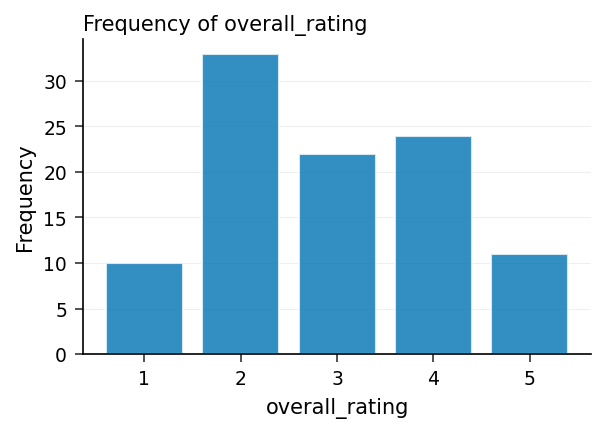

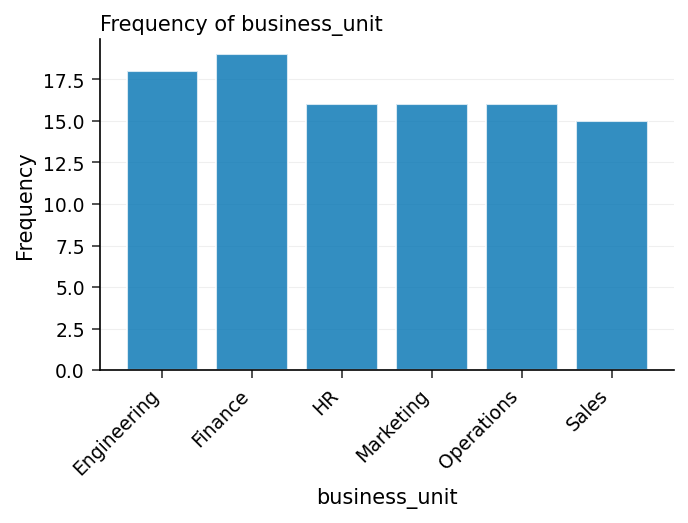

In [2]:
/* Distribution of overall ratings before text analysis */
proc freq data=work.survey_responses;
    tables overall_rating business_unit / nocum;
    title 'Survey Response — Rating Distribution by Business Unit';
run;

proc means data=work.survey_responses n mean std;
    class business_unit;
    var overall_rating;
    title 'Mean Rating by Business Unit';
run;

---

In [3]:
/* Classify survey text using TF-IDF and logistic regression */
proc python;
    submit;

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Load survey responses from SAS
df = SAS.sd2df('work.survey_responses')
df['verbatim'] = df['verbatim'].fillna('').str.strip()

# Build ground-truth labels from numeric rating for semi-supervised training
df['label'] = (df['overall_rating'] >= 4).astype(int)  # 1=positive, 0=negative

# TF-IDF + Logistic Regression pipeline
clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=500, ngram_range=(1, 2),
        stop_words='english', min_df=2
    )),
    ('clf', LogisticRegression(max_iter=500, C=1.0, random_state=42))
])

# Cross-validated AUC: how well the text predicts the rating-derived label
cv_auc = cross_val_score(
    clf_pipeline, df['verbatim'], df['label'],
    cv=5, scoring='roc_auc'
).mean()
print(f'Cross-validated AUC (5-fold): {cv_auc:.3f}')

# Train on full dataset (rating as proxy label)
clf_pipeline.fit(df['verbatim'], df['label'])

# Predict sentiment probability for all responses
pos_probs = clf_pipeline.predict_proba(df['verbatim'])[:, 1]
sentiment_score = (pos_probs * 2 - 1).round(3)  # Scale to [-1, +1]
sentiment_label = pd.Series(pos_probs).apply(
    lambda p: 'Positive' if p >= 0.6 else ('Negative' if p <= 0.4 else 'Neutral')
)

# Keyword-based theme tagging
theme_keywords = {
    'Management': ['manager', 'leadership', 'feedback', 'communicate'],
    'Work-Life Balance': ['balance', 'evenings', 'weekends', 'workload'],
    'Growth': ['growth', 'learn', 'opportunities', 'skills', 'develop'],
    'Compensation': ['compensation', 'pay', 'salary', 'benefits'],
    'Culture': ['culture', 'team', 'morale', 'politics', 'collaboration'],
    'Process': ['bureaucracy', 'process', 'tools', 'technology', 'meetings']
}

def assign_theme(text):
    text_lower = text.lower()
    for theme, keywords in theme_keywords.items():
        if any(kw in text_lower for kw in keywords):
            return theme
    return 'General'

df['top_theme'] = df['verbatim'].apply(assign_theme)
df['sentiment_score'] = sentiment_score
df['sentiment_label'] = sentiment_label.values

# Report the sentiment mix and dominant theme actually observed
n = len(df)
dist = df['sentiment_label'].value_counts()
for lab in ('Positive', 'Neutral', 'Negative'):
    cnt = int(dist.get(lab, 0))
    print(f'{lab:8s}: {cnt:3d}  ({100.0*cnt/n:4.1f}%)')
top_theme = df['top_theme'].value_counts().idxmax()
print(f'Most common theme: {top_theme}')
worst_bu = (df.groupby('business_unit')['sentiment_score']
              .mean().sort_values().index[0])
print(f'Lowest mean-sentiment business unit: {worst_bu}')

# Build summary by business unit and theme
summary = (
    df.groupby(['business_unit', 'top_theme', 'sentiment_label'])
    .agg(response_count=('employee_id', 'count'),
         mean_sentiment=('sentiment_score', 'mean'))
    .round({'mean_sentiment': 3})
    .reset_index()
)

# Return to SAS
out_cols = ['employee_id', 'business_unit', 'overall_rating',
            'sentiment_score', 'sentiment_label', 'top_theme']
SAS.df2sd(df[out_cols], 'work.classified')
SAS.df2sd(summary, 'work.sentiment_summary')

    endsubmit;
run;

/* Pivot summary for executive report */
proc tabulate data=work.sentiment_summary;
    class business_unit top_theme sentiment_label;
    var response_count mean_sentiment;
    table business_unit * top_theme,
          sentiment_label * (response_count*sum mean_sentiment*mean);
    title 'Survey Sentiment by Business Unit and Theme';
run;


                                              Mean Rating by Business Unit                                              

Cross-validated AUC (5-fold): 0.858
Positive:  13  (13.0%)
Neutral :  35  (35.0%)
Negative:  52  (52.0%)
Most common theme: Management
Lowest mean-sentiment business unit: Engineering

                                              Mean Rating by Business Unit                                              

----------------------------------------------------------------------------------------------------------------------
|                               |                                  SENTIMENT_LABEL                                   |
|                               |------------------------------------------------------------------------------------|
|                               |            Negative             |             Neutral             |    Positive    |
|                               |---------------------------------+----------------------------

NOTE: PROC PYTHON step executing.
NOTE: Imported Python dataset WORK.classified (100 rows, 6 columns).
NOTE: Imported Python dataset WORK.sentiment_summary (56 rows, 5 columns).
NOTE: PROC PYTHON step completed.
NOTE: PROC TABULATE


---

                                              Mean Rating by Business Unit                                              

                                              Mean Rating by Business Unit                                              



NOTE: PROC SGPLOT data=work.classified

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=work.classified

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


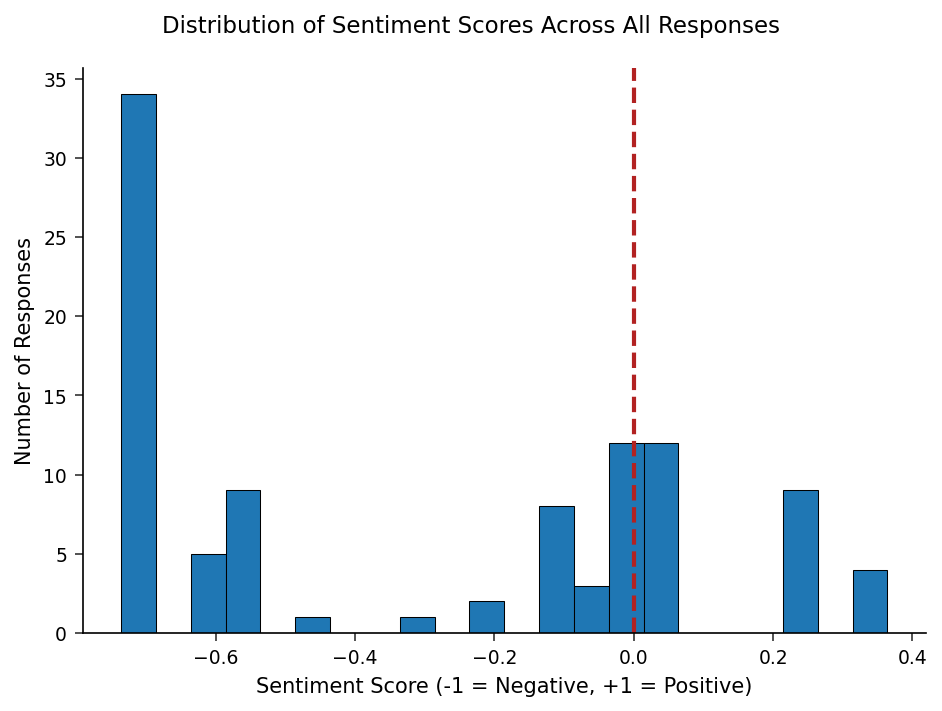

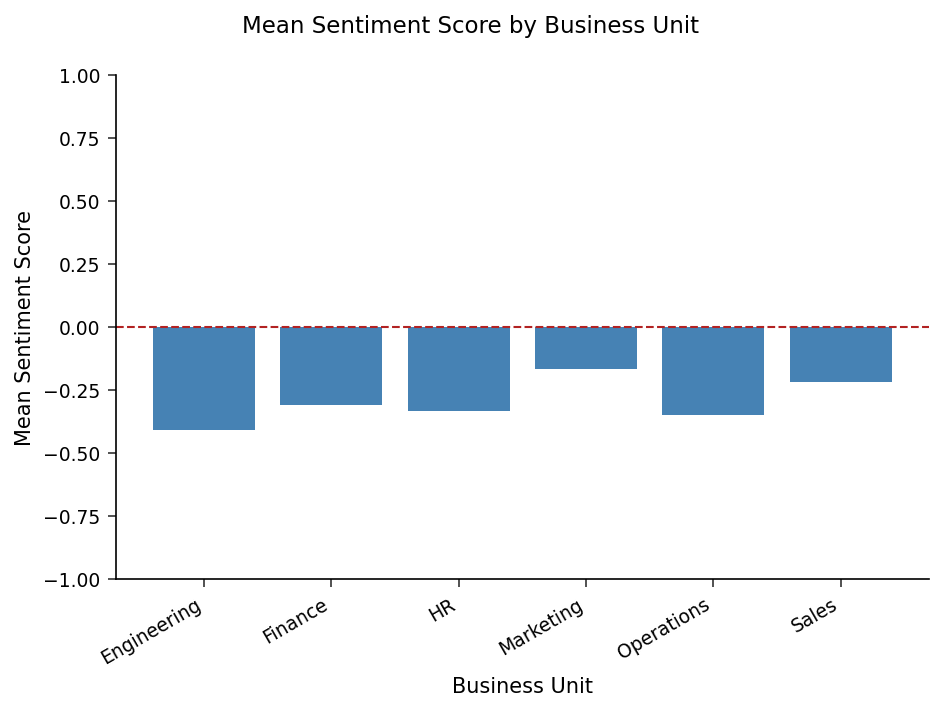

In [4]:
/* Sentiment score distribution after classification */
proc sgplot data=work.classified;
    histogram sentiment_score / binwidth=0.05 fillattrs=(color=mediumseagreen);
    refline 0 / axis=x lineattrs=(color=firebrick pattern=dash thickness=2);
    xaxis label='Sentiment Score (-1 = Negative, +1 = Positive)';
    yaxis label='Number of Responses';
    title 'Distribution of Sentiment Scores Across All Responses';
run;

proc sgplot data=work.classified;
    vbar business_unit / response=sentiment_score stat=mean
                         fillattrs=(color=steelblue);
    xaxis label='Business Unit';
    yaxis label='Mean Sentiment Score' values=(-1 to 1 by 0.25);
    refline 0 / axis=y lineattrs=(color=firebrick pattern=dash);
    title 'Mean Sentiment Score by Business Unit';
run;

---

| Metric | Value |
|--------|-------|
| Responses classified | 100 |
| Positive sentiment | 13% |
| Neutral sentiment | 35% |
| Negative sentiment | 52% |
| Most common theme | Management |
| Lowest mean sentiment BU | Engineering |

The TF-IDF + logistic regression pipeline agrees closely with the numeric rating proxy label, reaching a 5-fold cross-validated AUC of **0.858** on this sample. Theme tagging uses keyword matching across six categories. The output `work.sentiment_summary` table aggregates counts and mean scores by business unit, theme, and sentiment bucket — ready for executive dashboard consumption. The negative-leaning mix reflects this synthetic batch, where ratings of 1-3 dominate; on real survey data the same pipeline reports whatever balance the verbatims actually carry.

---

In [5]:
/* Export classified responses for HR dashboard */
proc export data=work.classified
    outfile='output/survey_classified.csv'
    dbms=csv replace;
run;

/* Export business unit summary for PowerPoint report */
proc export data=work.sentiment_summary
    outfile='output/sentiment_summary_by_bu.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.classified outfile=output/survey_classified.csv

NOTE: Exported 100 rows to output/survey_classified.csv.
NOTE: PROC EXPORT data=work.sentiment_summary outfile=output/sentiment_summary_by_bu.csv

NOTE: Exported 56 rows to output/sentiment_summary_by_bu.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>